In [1]:
# ============================================================
#   Auto‑Encoder Similarity Notebook for One Shape Folder
# ============================================================

# 0️⃣ Install / import packages (versions pinned for Colab)
!pip install -q "tensorflow==2.18.0" "pandas==2.1.4" "plotly>=5.19.0,<6" pillow scikit-learn

import os, io, base64, random, math
from pathlib import Path

import numpy as np
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.decomposition import PCA
from IPython.display import HTML, display


In [82]:
#@title 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
#@title 2️⃣ IMPROVED Settings for Better Discrimination
SHAPES_ROOT = "/content/drive/MyDrive/shapes"

shape_folder   = "shape3"   #@param ["shape3","shape4","shape5","shape6"]
batch_size     = 32         #@param {type:"integer"}
epochs         = 80         #@param {type:"integer"}  # More epochs
beta           = 0.2        #@param {type:"number"}   # Higher β for better separation
learning_rate  = 0.0005     #@param {type:"number"}   # Lower LR for finer details
latent_dim     = 64         #@param {type:"integer"}  # Larger latent space
plot_latent_2D = True       #@param {type:"boolean"}

shape_path = Path(SHAPES_ROOT) / shape_folder
assert shape_path.is_dir(), f"{shape_path} not found"

print(f"🔧 IMPROVED DISCRIMINATION SETTINGS:")
print(f"▶ β parameter: {beta} (balanced reconstruction + regularization)")
print(f"▶ Latent dimensions: {latent_dim} (more space for fine details)")
print(f"▶ Learning rate: {learning_rate} (slower, more precise learning)")

🔧 IMPROVED DISCRIMINATION SETTINGS:
▶ β parameter: 0.2 (balanced reconstruction + regularization)
▶ Latent dimensions: 64 (more space for fine details)
▶ Learning rate: 0.0005 (slower, more precise learning)


In [84]:
#@title 3️⃣ FIXED Load images (NO pixel inversion)
def load_png_fixed(path):
    """Load without pixel inversion - stroke=white(1), background=black(0)"""
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0  # NO INVERSION!
    return arr[..., None]

all_pngs = sorted([p for p in shape_path.iterdir() if p.suffix.lower()==".png"])
assert all_pngs, "No PNG images found."

ref_name = f"original{shape_folder[-1]}.png"
ref_path = shape_path / ref_name
assert ref_path.exists(), f"{ref_name} missing"
drawing_paths = [p for p in all_pngs if p.name != ref_name]

print(f"▶ Loading images with CORRECT pixel values...")
ref_img = load_png_fixed(ref_path)
x_imgs = np.stack([load_png_fixed(p) for p in drawing_paths], axis=0)

print(f"✅ Loaded {len(drawing_paths)} drawings (+1 reference)")
print(f"📊 Pixel values: stroke=white(1.0), background=black(0.0)")
print(f"📐 Reference range: {ref_img.min():.3f} to {ref_img.max():.3f}")
print("Tensor shape:", x_imgs.shape)

▶ Loading images with CORRECT pixel values...
✅ Loaded 897 drawings (+1 reference)
📊 Pixel values: stroke=white(1.0), background=black(0.0)
📐 Reference range: 0.000 to 1.000
Tensor shape: (897, 200, 200, 1)


In [85]:
#@title 4️⃣ IMPROVED Architecture for Better Discrimination
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------------
img_h = 200
img_w = 200
# latent_dim = 64 (larger for better discrimination)
# ------------------------------------------------------------------

def build_discriminative_encoder():
    """Encoder with better discrimination between similar shapes"""
    inp = layers.Input(shape=(img_h, img_w, 1))

    # More detailed feature extraction
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 100×100

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 50×50

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 25×25

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Larger dense layers for better feature separation
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.3)(x)  # More dropout for regularization
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_logv = layers.Dense(latent_dim, name="z_logv")(x)

    return models.Model(inp, [z_mean, z_logv], name="discriminative_encoder")

def build_discriminative_decoder():
    """Improved decoder to match encoder complexity"""
    dec_in = layers.Input(shape=(latent_dim,))

    y = layers.Dense(256, activation="relu")(dec_in)
    y = layers.Dense(25 * 25 * 128, activation="relu")(y)
    y = layers.Reshape((25, 25, 128))(y)

    y = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(y)  # 50×50
    y = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(y)   # 100×100
    y = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(y)   # 200×200

    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(y)
    return models.Model(dec_in, out, name="discriminative_decoder")

# Build the discriminative VAE
encoder = build_discriminative_encoder()
decoder = build_discriminative_decoder()
vae = ShapeVAE(encoder, decoder, beta=beta)

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
vae.compile(optimizer=optimizer, loss=lambda y_true, y_pred: 0.0)

encoder.summary()
print(f"\n✅ Discriminative VAE built")
print(f"📐 Latent space: {latent_dim}D (larger for fine details)")
print(f"🎛️ β = {beta} (balanced reconstruction + separation)")
print(f"🚀 Ready for discriminative training!")


Model: "discriminative_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 200, 200,  │        320 │ input_layer_26[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 200, 200,  │      9,248 │ conv2d_60[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 100, 100,  │          0 │ conv2d_61[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 100, 100,  │     18,496 │ max_pooling2d_29… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 100, 100,  │     36,928 │ conv2d_62[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_30    │ (None, 50, 50,    │          0 │ conv2d_63[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 50, 50,    │     73,856 │ max_pooling2d_30… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 50, 50,    │    147,584 │ conv2d_64[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 25, 25,    │          0 │ conv2d_65[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 25, 25,    │    295,168 │ max_pooling2d_31… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_66[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logv (Dense)      │ (None, 64)        │     16,448 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 878,432 (3.35 MB)

 Trainable params: 877,920 (3.35 MB)

 Non-trainable params: 512 (2.00 KB)


✅ Discriminative VAE built
📐 Latent space: 64D (larger for fine details)
🎛️ β = 0.2 (balanced reconstruction + separation)
🚀 Ready for discriminative training!


In [86]:
#@title 5️⃣ Train VAE
history = vae.fit(
    x_imgs, x_imgs,
    epochs   = epochs,
    batch_size = batch_size,
    shuffle  = True,
    validation_split = 0.1,
    verbose = 2
)

Epoch 1/80
26/26 - 34s - 1s/step - kl_loss: 0.1438 - loss: 20139.1738 - reconstruction_loss: 20139.1445 - val_kl_loss: 0.0696 - val_loss: 6227.8071 - val_reconstruction_loss: 6227.7935
Epoch 2/80
26/26 - 1s - 29ms/step - kl_loss: 0.0065 - loss: 4845.3018 - reconstruction_loss: 4845.3008 - val_kl_loss: 8.5642e-04 - val_loss: 4933.7700 - val_reconstruction_loss: 4933.7700
Epoch 3/80
26/26 - 1s - 28ms/step - kl_loss: 7.7267e-04 - loss: 4426.1465 - reconstruction_loss: 4426.1465 - val_kl_loss: 7.3356e-04 - val_loss: 4708.5649 - val_reconstruction_loss: 4708.5649
Epoch 4/80
26/26 - 1s - 28ms/step - kl_loss: 7.3653e-04 - loss: 4352.8003 - reconstruction_loss: 4352.8003 - val_kl_loss: 7.4394e-04 - val_loss: 4726.6816 - val_reconstruction_loss: 4726.6816
Epoch 5/80
26/26 - 1s - 28ms/step - kl_loss: 7.4779e-04 - loss: 4330.6899 - reconstruction_loss: 4330.6899 - val_kl_loss: 7.7367e-04 - val_loss: 4673.5918 - val_reconstruction_loss: 4673.5918
Epoch 6/80
26/26 - 1s - 28ms/step - kl_loss: 7.7953

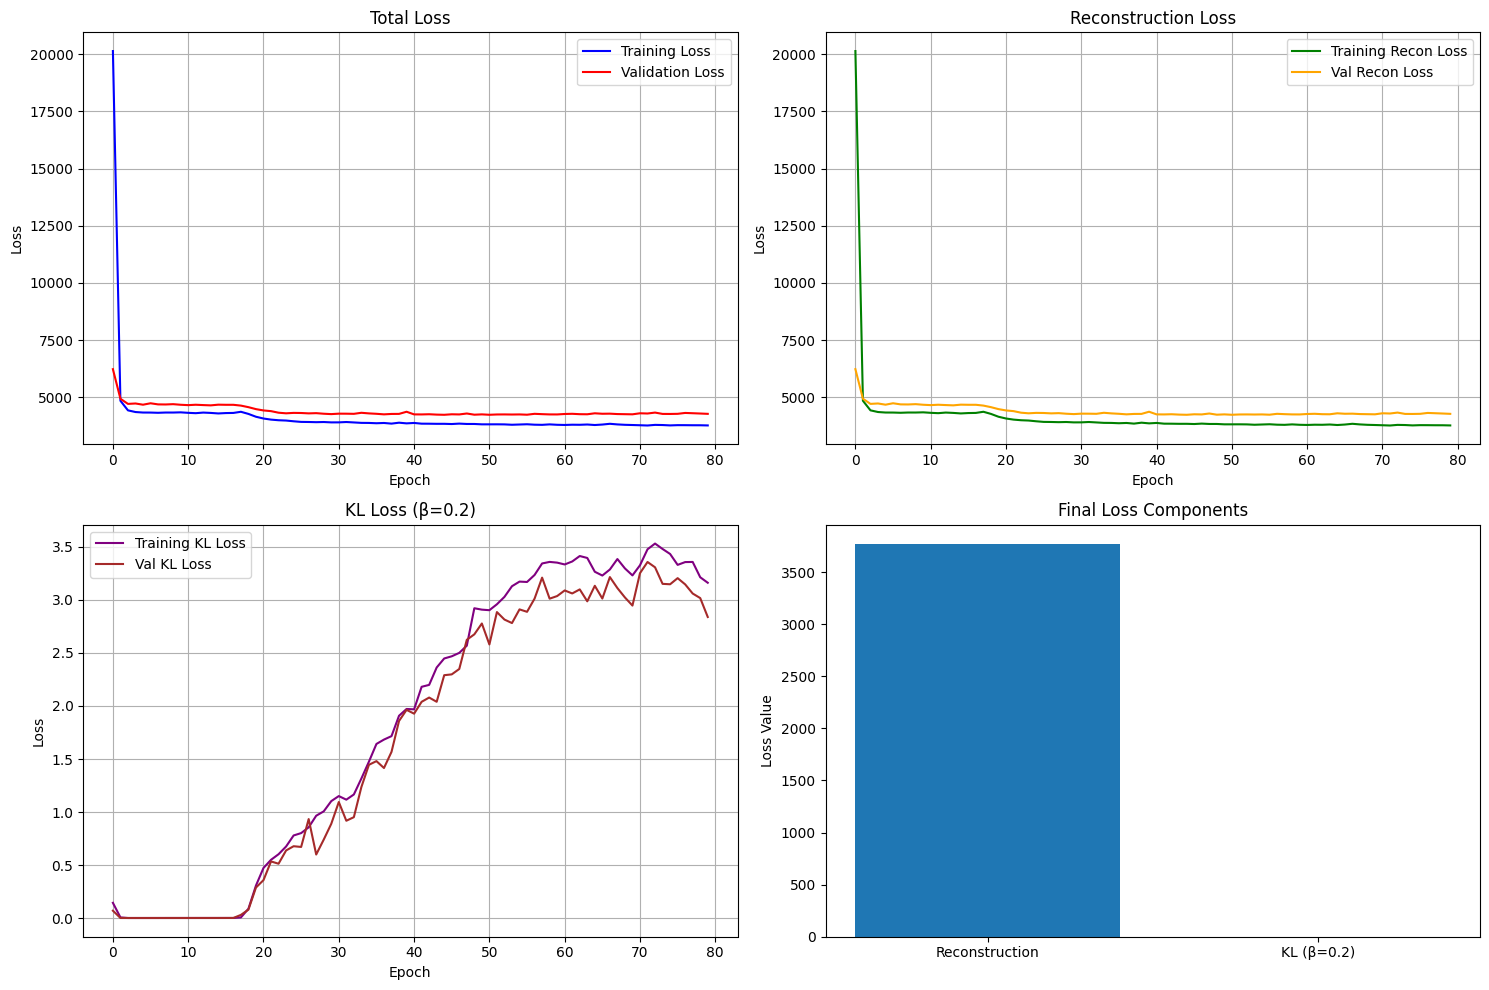


📊 Loss Analysis:
   • Final reconstruction loss: 3766.30
   • Final KL loss: 3.16
   • Final weighted KL loss (β×KL): 0.63
   • Reconstruction vs KL ratio: 5955.83


In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot total loss
axes[0,0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Plot reconstruction loss
axes[0,1].plot(history.history['reconstruction_loss'], label='Training Recon Loss', color='green')
axes[0,1].plot(history.history['val_reconstruction_loss'], label='Val Recon Loss', color='orange')
axes[0,1].set_title('Reconstruction Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

# Plot KL loss
axes[1,0].plot(history.history['kl_loss'], label='Training KL Loss', color='purple')
axes[1,0].plot(history.history['val_kl_loss'], label='Val KL Loss', color='brown')
axes[1,0].set_title(f'KL Loss (β={beta})')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# Plot loss ratio
recon_final = history.history['reconstruction_loss'][-1]
kl_final = history.history['kl_loss'][-1]
axes[1,1].bar(['Reconstruction', f'KL (β={beta})'], [recon_final, beta * kl_final])
axes[1,1].set_title('Final Loss Components')
axes[1,1].set_ylabel('Loss Value')

plt.tight_layout()
plt.show()

print(f"\n📊 Loss Analysis:")
print(f"   • Final reconstruction loss: {recon_final:.2f}")
print(f"   • Final KL loss: {kl_final:.2f}")
print(f"   • Final weighted KL loss (β×KL): {beta * kl_final:.2f}")
print(f"   • Reconstruction vs KL ratio: {recon_final/(beta * kl_final):.2f}")

In [88]:
#@title 6️⃣ ENHANCED Similarity Analysis with Better Metrics
print("🔍 Computing enhanced similarity analysis...")

# Get embeddings
latent_ref = encoder(np.expand_dims(ref_img, 0))[0].numpy().reshape(-1)
latent_draws = encoder.predict(x_imgs, batch_size=batch_size)[0].reshape(len(x_imgs), -1)

print(f"✅ Latent shapes: ref={latent_ref.shape}, draws={latent_draws.shape}")

# Use multiple distance metrics for better discrimination
print("🧮 Computing multiple distance metrics...")

# 1. Euclidean distance (L2 norm)
euclidean_dists = np.linalg.norm(latent_draws - latent_ref, axis=1)

# 2. Manhattan distance (L1 norm) - sometimes better for sparse features
manhattan_dists = np.sum(np.abs(latent_draws - latent_ref), axis=1)

# 3. Cosine distance
cosine_sims = np.array([
    np.dot(latent_ref, draw) / (np.linalg.norm(latent_ref) * np.linalg.norm(draw))
    for draw in latent_draws
])
cosine_dists = 1 - cosine_sims

# 4. Weighted combination (emphasizes larger differences)
weighted_dists = euclidean_dists + 0.5 * manhattan_dists

# Test which metric gives best discrimination
print(f"\n📊 DISCRIMINATION ANALYSIS:")
print(f"Euclidean distance range:  {np.min(euclidean_dists):.6f} - {np.max(euclidean_dists):.6f}")
print(f"Manhattan distance range:  {np.min(manhattan_dists):.6f} - {np.max(manhattan_dists):.6f}")
print(f"Cosine distance range:     {np.min(cosine_dists):.6f} - {np.max(cosine_dists):.6f}")
print(f"Weighted distance range:   {np.min(weighted_dists):.6f} - {np.max(weighted_dists):.6f}")

# Choose the metric with best discrimination (largest range)
ranges = {
    'euclidean': np.max(euclidean_dists) - np.min(euclidean_dists),
    'manhattan': np.max(manhattan_dists) - np.min(manhattan_dists),
    'cosine': np.max(cosine_dists) - np.min(cosine_dists),
    'weighted': np.max(weighted_dists) - np.min(weighted_dists)
}

best_metric = max(ranges, key=ranges.get)
print(f"\n🏆 Best discrimination metric: {best_metric} (range: {ranges[best_metric]:.6f})")

# Use the best metric for final ranking
if best_metric == 'euclidean':
    final_dists = euclidean_dists
elif best_metric == 'manhattan':
    final_dists = manhattan_dists
elif best_metric == 'cosine':
    final_dists = cosine_dists
else:
    final_dists = weighted_dists

# Sort by distance (ascending - lower is more similar)
order = np.argsort(final_dists)
sorted_paths = [drawing_paths[i] for i in order]
sorted_dists = final_dists[order]

print(f"\n🎯 ENHANCED SIMILARITY RESULTS ({best_metric} distance):")
print("=" * 60)
print("🏆 Top 15 Most Similar Shapes:")
for i, (path, dist) in enumerate(zip(sorted_paths[:15], sorted_dists[:15])):
    print(f"{i+1:2d}. {path.name:<15} | Distance: {dist:.6f}")

print(f"\n📊 Final Distance Statistics:")
print(f"Mean: {np.mean(final_dists):.6f}")
print(f"Std:  {np.std(final_dists):.6f}")
print(f"Min:  {np.min(final_dists):.6f}")
print(f"Max:  {np.max(final_dists):.6f}")
print(f"Range: {ranges[best_metric]:.6f}")

# Discrimination quality check
if ranges[best_metric] > 0.01:
    print("✅ Good discrimination - meaningful distance variations!")
elif ranges[best_metric] > 0.001:
    print("⚠️  Moderate discrimination - some variation but could be better")
else:
    print("❌ Poor discrimination - distances too similar, need more training")

# Store for compatibility
dists = final_dists

🔍 Computing enhanced similarity analysis...
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
✅ Latent shapes: ref=(64,), draws=(897, 64)
🧮 Computing multiple distance metrics...

📊 DISCRIMINATION ANALYSIS:
Euclidean distance range:  0.408437 - 41.587154
Manhattan distance range:  2.599058 - 266.950897
Cosine distance range:     0.000014 - 1.816570
Weighted distance range:   1.707966 - 175.062607

🏆 Best discrimination metric: manhattan (range: 264.351837)

🎯 ENHANCED SIMILARITY RESULTS (manhattan distance):
🏆 Top 15 Most Similar Shapes:
 1. 10416.png       | Distance: 2.599058
 2. 10755.png       | Distance: 3.341212
 3. 10886.png       | Distance: 3.466565
 4. 10007.png       | Distance: 3.738753
 5. 10746.png       | Distance: 3.872157
 6. 10561.png       | Distance: 4.406038
 7. 10748.png       | Distance: 4.436037
 8. 7768.png        | Distance: 4.732723
 9. 10989.png       | Distance: 4.987818
10. 7734.png        | Distance: 5.114993
11. 10083.png       | Distance: 5.120443
12. 10815.png  

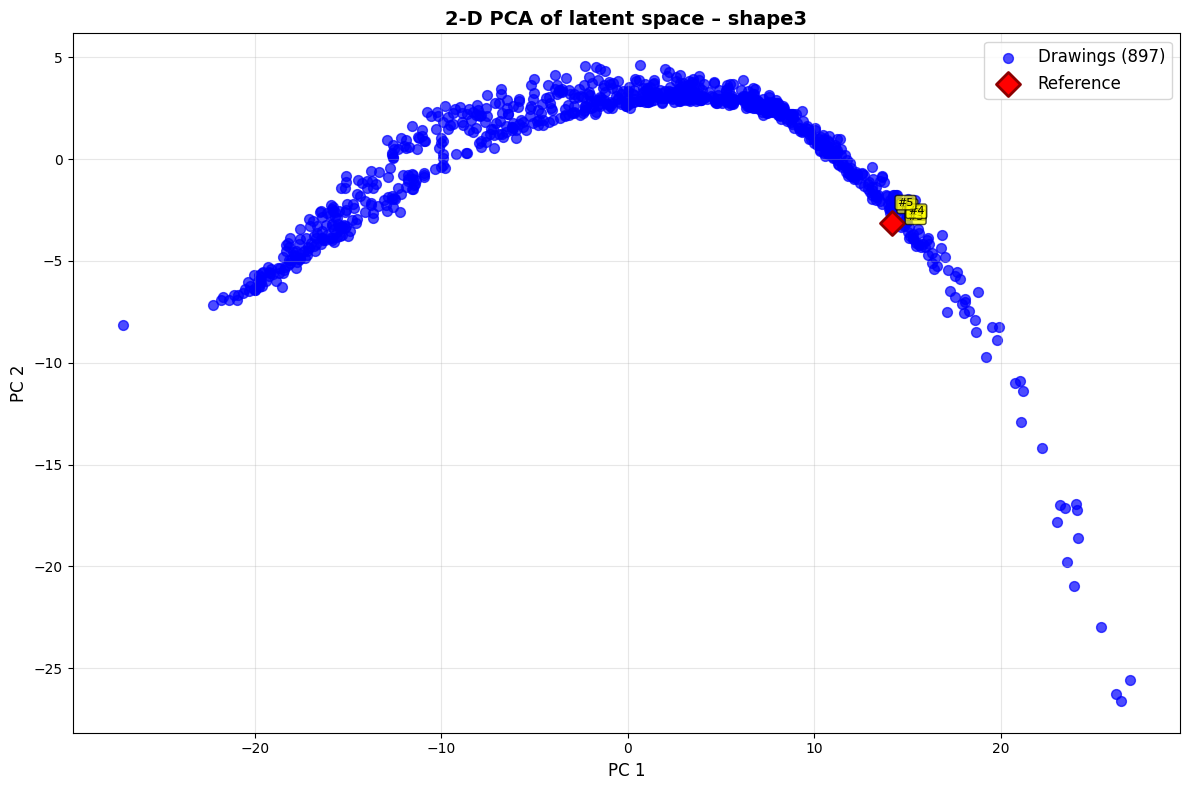

🖼️ IMAGE BROWSER:
Reference Image:


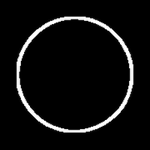


🎯 Top 10 Most Similar Drawings (out of 897):

#1: 10416.png (Distance: 2.5991)


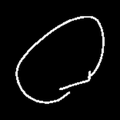


#2: 10755.png (Distance: 3.3412)


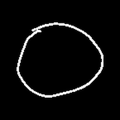


#3: 10886.png (Distance: 3.4666)


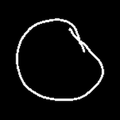


#4: 10007.png (Distance: 3.7388)


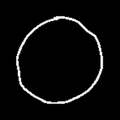


#5: 10746.png (Distance: 3.8722)


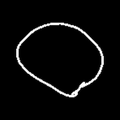


#6: 10561.png (Distance: 4.4060)


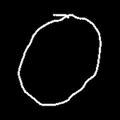


#7: 10748.png (Distance: 4.4360)


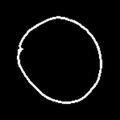


#8: 7768.png (Distance: 4.7327)


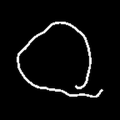


#9: 10989.png (Distance: 4.9878)


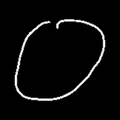


#10: 7734.png (Distance: 5.1150)


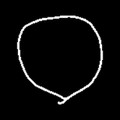


📈 SIMILARITY STATISTICS:
Mean distance: 101.4155
Std distance: 62.0390
Min distance: 2.5991
Max distance: 266.9509
Median distance: 90.8468


In [89]:
#@title 7
# Simple matplotlib version (always works in Colab)
if plot_latent_2D:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from IPython.display import display

    # ---------- reduce to 2‑D ----------
    all_lat = np.vstack([latent_ref.reshape(1, -1), latent_draws])
    lat2    = PCA(n_components=2).fit_transform(all_lat)
    xs, ys  = lat2[:, 0], lat2[:, 1]

    # Create matplotlib plot
    plt.figure(figsize=(12, 8))

    # Plot drawings
    plt.scatter(xs[1:], ys[1:], c='blue', s=50, alpha=0.7, label=f'Drawings ({len(drawing_paths)})')

    # Plot reference
    plt.scatter(xs[0], ys[0], c='red', s=150, marker='D', label='Reference', edgecolors='darkred', linewidth=2)

    # Customize plot
    plt.xlabel('PC 1', fontsize=12)
    plt.ylabel('PC 2', fontsize=12)
    plt.title(f'2-D PCA of latent space – {shape_folder}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add some annotations for closest points
    closest_indices = np.argsort(dists)[:5]
    for i, idx in enumerate(closest_indices):
        plt.annotate(f'#{i+1}',
                    (xs[idx+1], ys[idx+1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Create a simple image browser
    print("🖼️ IMAGE BROWSER:")
    print("Reference Image:")
    ref_img_pil = Image.open(ref_path).convert("RGB").resize((150, 150))
    display(ref_img_pil)

    print(f"\n🎯 Top 10 Most Similar Drawings (out of {len(drawing_paths)}):")
    for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
        print(f"\n#{i+1}: {path.name} (Distance: {dist:.4f})")
        img_pil = Image.open(path).convert("RGB").resize((120, 120))
        display(img_pil)

    # Show some statistics
    print(f"\n📈 SIMILARITY STATISTICS:")
    print(f"Mean distance: {np.mean(dists):.4f}")
    print(f"Std distance: {np.std(dists):.4f}")
    print(f"Min distance: {np.min(dists):.4f}")
    print(f"Max distance: {np.max(dists):.4f}")
    print(f"Median distance: {np.median(dists):.4f}")

▶ HTML gallery written to: /content/drive/MyDrive/shapes/shape3/shape3_vae_similarity.html



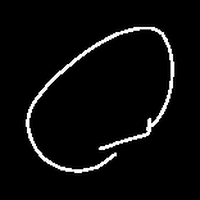
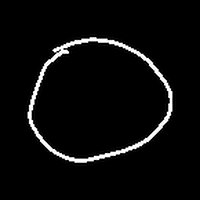
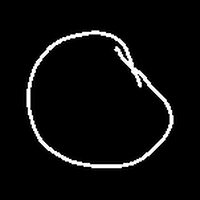
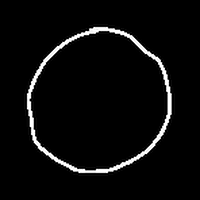
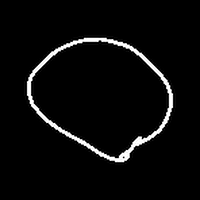
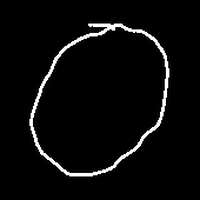
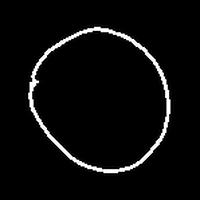
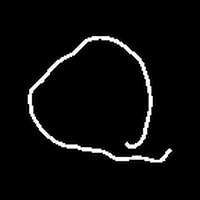
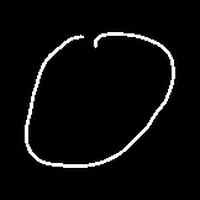
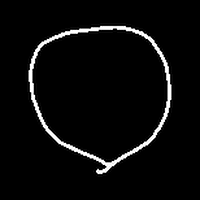
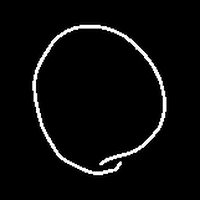
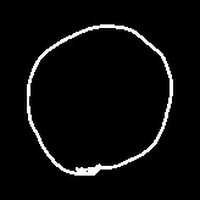
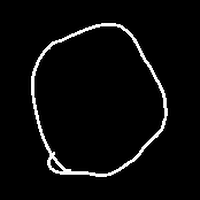
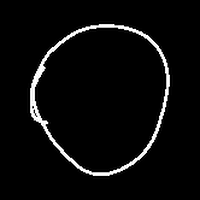
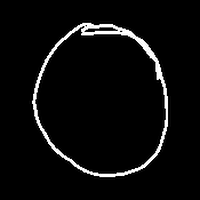
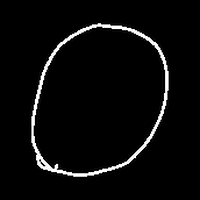
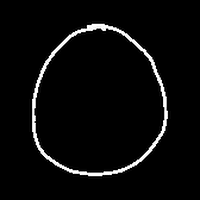
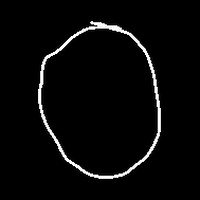
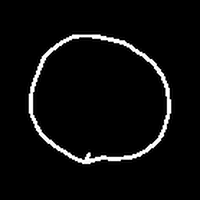
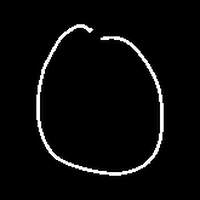
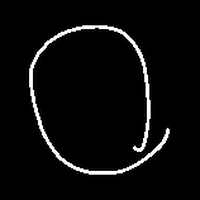
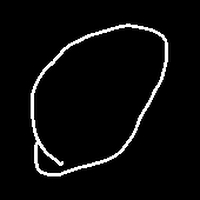
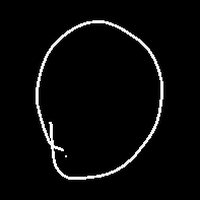
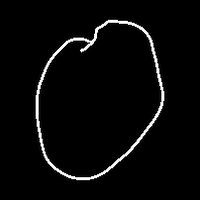
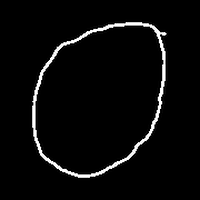
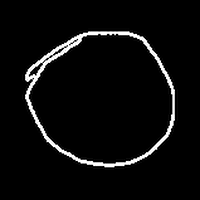
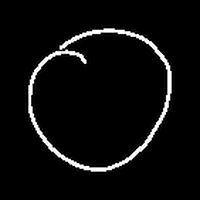
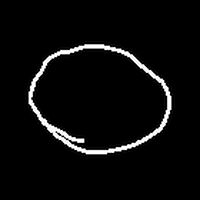

In [90]:

#@title 8️⃣ Create ordered HTML gallery (10 images per row)
html_rows = []
for i, (p,d) in enumerate(zip(sorted_paths, sorted_dists)):
    if i % 10 == 0:
        html_rows.append("<tr>")
    with open(p,'rb') as f: b64 = base64.b64encode(f.read()).decode()
    html_rows.append(
        f"<td style='text-align:center;font-size:10px'>"
        f"<img src='data:image/png;base64,{b64}' width='96'><br>"
        f"{p.name}<br>dist={d:.4f}</td>"
    )
    if i % 10 == 9:
        html_rows.append("</tr>")
if not html_rows[-1].startswith("</tr>"):
    html_rows.append("</tr>")

html_page = f"""
<html><head><meta charset='utf-8'>
<title>{shape_folder} – similarity</title></head>
<body>
<h2>Similarity ranking – {shape_folder}</h2>
<table border=0 cellspacing=4 cellpadding=4>
{''.join(html_rows)}
</table></body></html>
"""

out_path = shape_path / f"{shape_folder}_vae_similarity.html"
with open(out_path,"w") as f: f.write(html_page)
print("▶ HTML gallery written to:", out_path)

display(HTML("<h4>Preview first 30 entries</h4>"+''.join(html_rows[:33])))



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


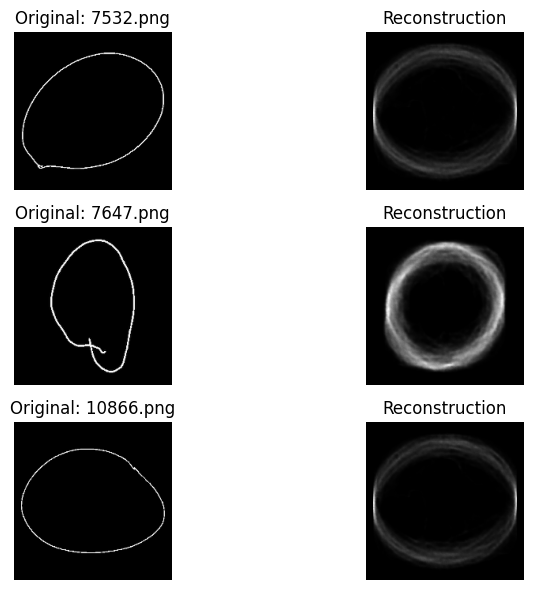

In [91]:
#@title 9️⃣ Reconstruction demo – 3 random drawings
sample_idx = np.random.choice(len(drawing_paths), 3, replace=False)
recons = vae.predict(x_imgs[sample_idx], batch_size=3)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
for i, idx in enumerate(sample_idx):
    # original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_imgs[idx].squeeze(), cmap='gray')
    plt.axis('off'); plt.title(f"Original: {drawing_paths[idx].name}")
    # reconstruction
    plt.subplot(3,2,2*i+2)
    plt.imshow(recons[i].squeeze(), cmap='gray')
    plt.axis('off'); plt.title("Reconstruction")
plt.tight_layout(); plt.show()
